# MAST Shot 30420 - Triple Product Analysis

This notebook analyzes shot 30420 and calculates the fusion triple product: **n × T × τ**

The triple product is a key metric for fusion performance:
- **n**: Plasma density (m⁻³)
- **T**: Plasma temperature (keV)
- **τ**: Energy confinement time (s)

## Import Libraries

In [9]:
import zarr
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rcParams, rc

# Set plotting style
plt.style.use('ggplot')
rcParams['font.size'] = 10
rcParams['axes.grid'] = True
rcParams['grid.color'] = (0.5, 0.5, 0.5, 0.1)
rc('font', family='arial narrow')

## Load Data from Zarr Store

In [10]:
# Open the zarr store
store = zarr.open('30421.zarr', mode='r')

# Load summary data
summary = store['summary']
equilibrium = store['equilibrium']

# Extract time series data
time = np.array(summary['time'])
n_e = np.array(summary['line_average_n_e'])  # Line-averaged electron density (m^-3)
power_ohm = np.array(summary['power_ohm'])  # Ohmic heating power (W)

# Load NBI power if available, otherwise assume zero
try:
    power_nbi = np.array(summary['power_nbi'])  # NBI heating power (W)
except KeyError:
    power_nbi = np.zeros_like(time)  # No NBI data available
    print("Note: power_nbi not found, assuming zero NBI power")

power_rad = np.array(summary['power_radiated'])  # Radiated power (W)

# Load stored energy from equilibrium
time_eq = np.array(equilibrium['time'])
wmhd = np.array(equilibrium['wmhd'])  # Stored energy (J)
volumes = np.array(equilibrium['volume'])

clip_time = 0.15  # Time threshold for clipping (s)
# --- CLIP ALL SIGNALS TO time > clip_time ---
clip_mask = time > clip_time

time = time[clip_mask]
n_e = n_e[clip_mask]
power_ohm = power_ohm[clip_mask]
power_nbi = power_nbi[clip_mask]
power_rad = power_rad[clip_mask]

# For equilibrium signals, clip to matching time range if needed
if time_eq[0] <= clip_time:
    eq_clip_mask = time_eq > clip_time
    time_eq = time_eq[eq_clip_mask]
    wmhd = wmhd[eq_clip_mask]
    volumes = volumes[eq_clip_mask]

print(f"Time range: {time[0]:.3f} - {time[-1]:.3f} s")
print(f"Number of time points (summary): {len(time)}")
print(f"Number of time points (equilibrium): {len(time_eq)}")

Time range: 0.151 - 0.666 s
Number of time points (summary): 516
Number of time points (equilibrium): 104


NBI Power Statistics:
  Min: -1.91e+01 W = -0.00 MW
  Max: 3.67e+06 W = 3.67 MW
  Mean: 2.93e+06 W = 2.93 MW
  Non-zero values: 514/516


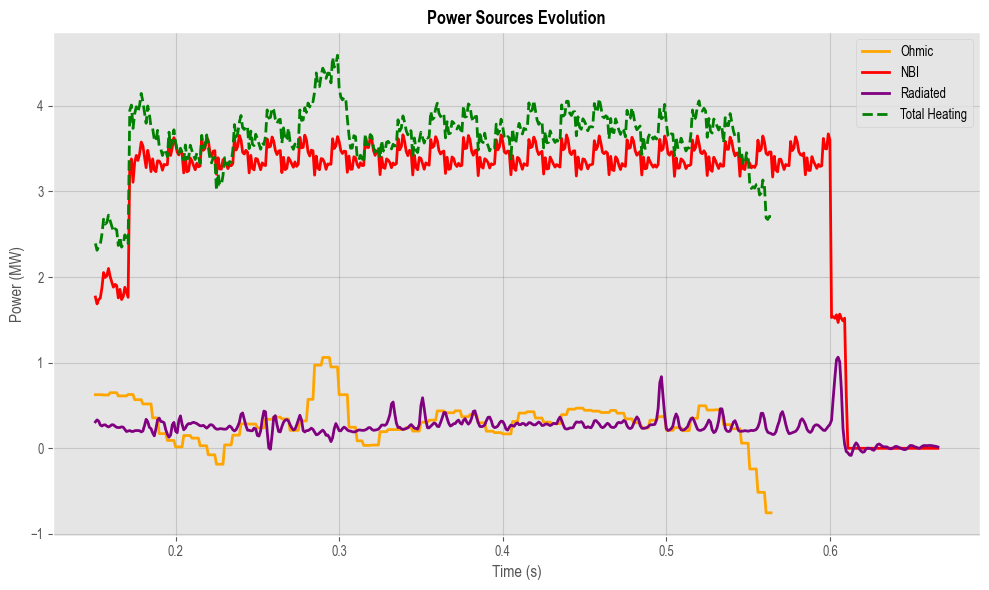

In [11]:
# Check NBI power data
print("NBI Power Statistics:")
print(f"  Min: {np.min(power_nbi):.2e} W = {np.min(power_nbi)/1e6:.2f} MW")
print(f"  Max: {np.max(power_nbi):.2e} W = {np.max(power_nbi)/1e6:.2f} MW")
print(f"  Mean: {np.mean(power_nbi):.2e} W = {np.mean(power_nbi)/1e6:.2f} MW")
print(f"  Non-zero values: {np.sum(power_nbi > 0)}/{len(power_nbi)}")

# Quick plot to visualize all power sources
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(time, power_ohm / 1e6, 'orange', linewidth=2, label='Ohmic')
ax.plot(time, power_nbi / 1e6, 'red', linewidth=2, label='NBI')
ax.plot(time, power_rad / 1e6, 'purple', linewidth=2, label='Radiated')
ax.plot(time, (power_ohm + power_nbi) / 1e6, 'green', linewidth=2, linestyle='--', label='Total Heating')
ax.set_xlabel('Time (s)', fontsize=12)
ax.set_ylabel('Power (MW)', fontsize=12)
ax.set_title('Power Sources Evolution', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Calculate Triple Product Components

### 1. Density (n)
Already available as line-averaged electron density

### 2. Temperature (T)
Estimate from stored energy: $T_e \approx \frac{2 W_{MHD}}{3 n_e V}$

Volume V is calculated dynamically from the LCFS boundary

### 3. Energy Confinement Time (τ_E)
$\tau_E = \frac{W_{MHD}}{P_{heating} - P_{rad}}$ where $P_{heating} = P_{ohm} + P_{NBI}$

In [12]:
# Interpolate wmhd to summary time base (already done above for V_plasma)
wmhd_interp = np.interp(time, time_eq, wmhd)
V_plasma = np.interp(time, time_eq, volumes)

# Calculate total heating power and net power
p_heating = power_ohm + power_nbi  # Total heating power (W)
p_net = p_heating - power_rad  # Net power to plasma (W)

# Calculate energy confinement time (avoid division by zero)
tau_e = np.where(p_net > 1e3, wmhd_interp / p_net, np.nan)

# Estimate temperature using dynamic plasma volume
# T_e ~ (2/3) * W_MHD / (n_e * V)
eV_to_J = 1.602e-19  # Conversion factor

# Calculate average temperature in eV using the time-dependent volume
T_e_eV = np.where((n_e > 0) & (V_plasma > 0), 
                  (2/3) * wmhd_interp / (n_e * V_plasma * eV_to_J), 
                  np.nan)
T_e_keV = T_e_eV / 1000  # Convert to keV

# Calculate triple product: n * T * tau
# Units: (m^-3) * (keV) * (s) = m^-3 keV s
triple_product = n_e * T_e_keV * tau_e

print("Calculated triple product components:")
print(f"Max density: {np.nanmax(n_e):.2e} m^-3")
print(f"Max temperature: {np.nanmax(T_e_keV):.2f} keV")
print(f"Max confinement time: {np.nanmax(tau_e):.4f} s")
print(f"Max triple product: {np.nanmax(triple_product):.2e} m^-3 keV s")
print(f"\nVolume range used: {np.nanmin(V_plasma):.2f} - {np.nanmax(V_plasma):.2f} m³")

Calculated triple product components:
Max density: 3.56e+19 m^-3
Max temperature: 3.44 keV
Max confinement time: 0.0497 s
Max triple product: 3.75e+18 m^-3 keV s

Volume range used: 6.35 - 7.58 m³


In [13]:
# --- DIAGNOSTIC: Print max/min/mean values for all triple product components ---
print("\nSanity check for triple product components:")
print(f"  n_e: min={np.nanmin(n_e):.2e}, max={np.nanmax(n_e):.2e}, mean={np.nanmean(n_e):.2e} m^-3")
print(f"  T_e_keV: min={np.nanmin(T_e_keV):.2f}, max={np.nanmax(T_e_keV):.2f}, mean={np.nanmean(T_e_keV):.2f} keV")
print(f"  tau_e: min={np.nanmin(tau_e):.4f}, max={np.nanmax(tau_e):.4f}, mean={np.nanmean(tau_e):.4f} s")
print(f"  V_plasma: min={np.nanmin(V_plasma):.2f}, max={np.nanmax(V_plasma):.2f}, mean={np.nanmean(V_plasma):.2f} m^3")
print(f"  wmhd_interp: min={np.nanmin(wmhd_interp):.2f}, max={np.nanmax(wmhd_interp):.2f}, mean={np.nanmean(wmhd_interp):.2f} J")


Sanity check for triple product components:
  n_e: min=0.00e+00, max=3.56e+19, mean=2.50e+19 m^-3
  T_e_keV: min=1.68, max=3.44, mean=2.63 keV
  tau_e: min=0.0264, max=0.0497, mean=0.0374 s
  V_plasma: min=6.35, max=7.58, mean=7.06 m^3
  wmhd_interp: min=85404.55, max=137470.42, mean=125020.20 J


## Plot Triple Product Evolution

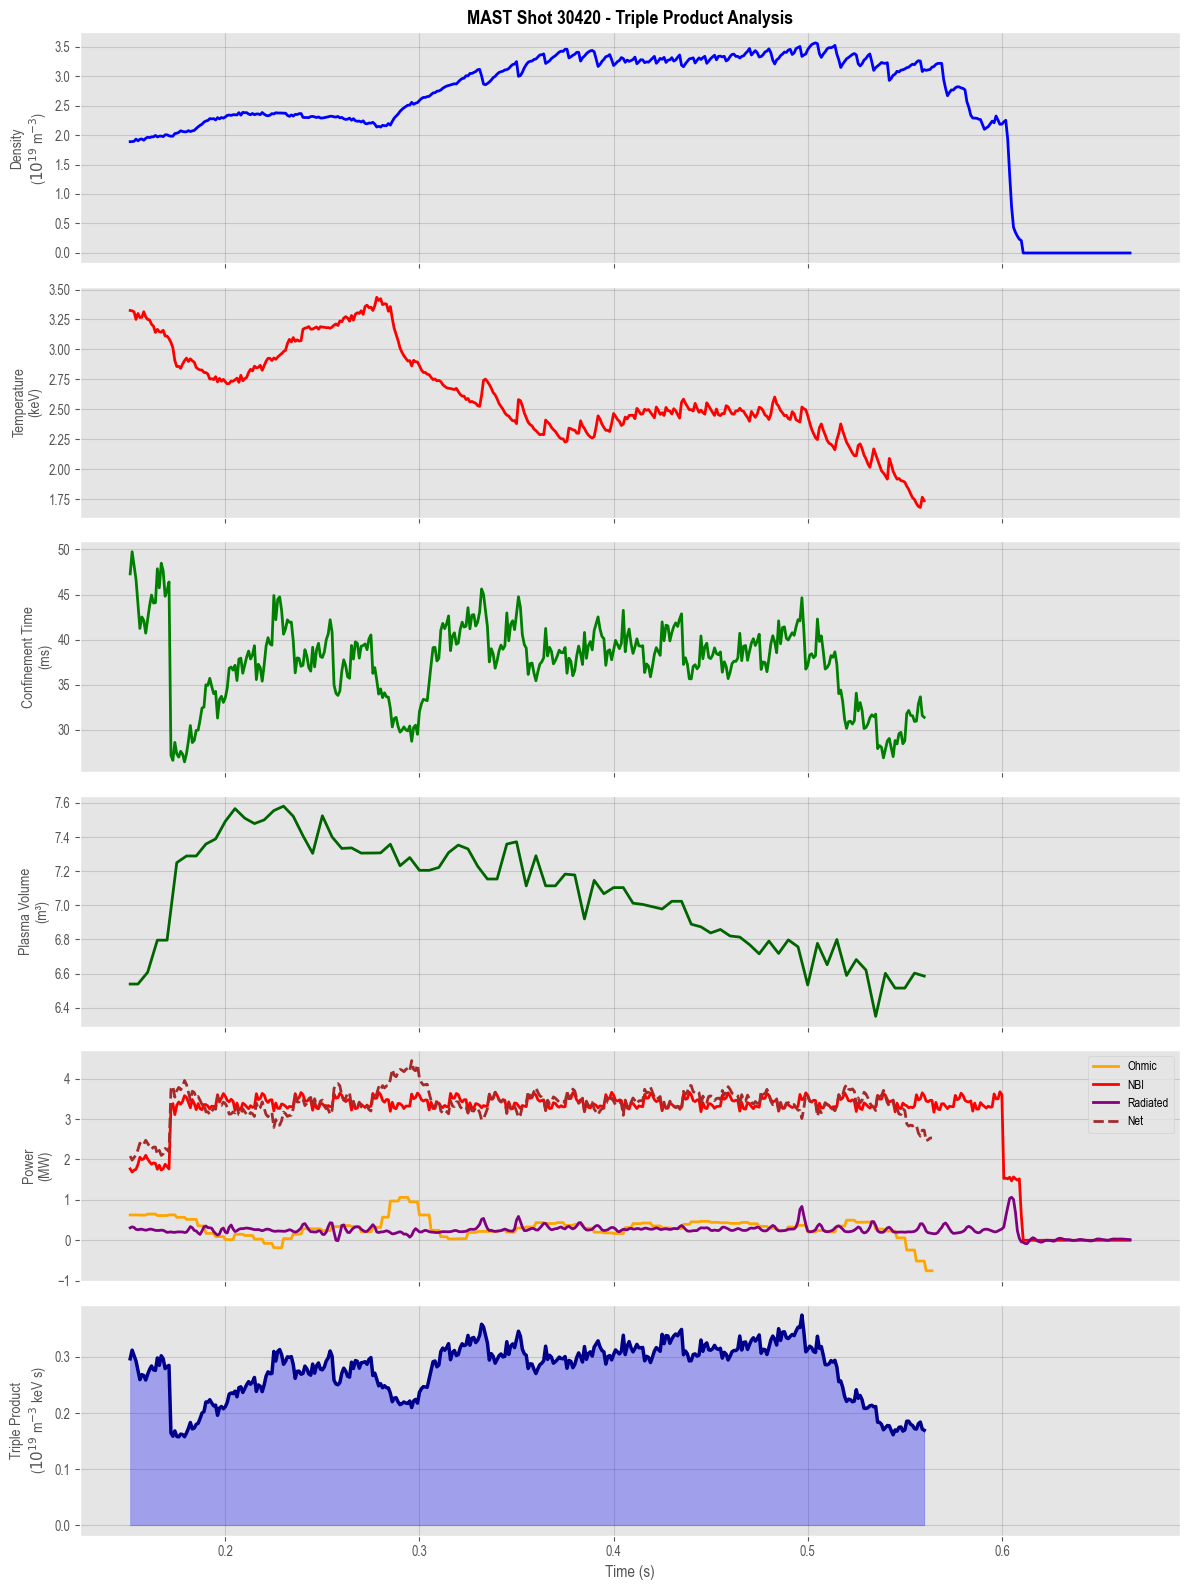


Peak triple product: 3.75e+18 m^-3 keV s
Occurs at time: 0.497 s
  n_e = 3.33e+19 m^-3
  T_e = 2.52 keV
  τ_E = 44.64 ms
  V = 6.67 m³


In [14]:
fig, axes = plt.subplots(6, 1, figsize=(12, 16), sharex=True)

# Plot 1: Density
axes[0].plot(time, n_e / 1e19, 'b-', linewidth=2)
axes[0].set_ylabel('Density\n($10^{19}$ m$^{-3}$)', fontsize=11)
axes[0].grid(True, alpha=0.3)
axes[0].set_title('MAST Shot 30420 - Triple Product Analysis', fontsize=14, fontweight='bold')

# Plot 2: Temperature
axes[1].plot(time, T_e_keV, 'r-', linewidth=2)
axes[1].set_ylabel('Temperature\n(keV)', fontsize=11)
axes[1].grid(True, alpha=0.3)

# Plot 3: Confinement Time
axes[2].plot(time, tau_e * 1000, 'g-', linewidth=2)
axes[2].set_ylabel('Confinement Time\n(ms)', fontsize=11)
axes[2].grid(True, alpha=0.3)

# Plot 4: Plasma Volume
axes[3].plot(time, V_plasma, 'darkgreen', linewidth=2)
axes[3].set_ylabel('Plasma Volume\n(m³)', fontsize=11)
axes[3].grid(True, alpha=0.3)

# Plot 5: Power
axes[4].plot(time, power_ohm / 1e6, 'orange', linewidth=2, label='Ohmic')
axes[4].plot(time, power_nbi / 1e6, 'red', linewidth=2, label='NBI')
axes[4].plot(time, power_rad / 1e6, 'purple', linewidth=2, label='Radiated')
axes[4].plot(time, p_net / 1e6, 'brown', linewidth=2, linestyle='--', label='Net')
axes[4].set_ylabel('Power\n(MW)', fontsize=11)
axes[4].legend(loc='upper right', fontsize=9)
axes[4].grid(True, alpha=0.3)

# Plot 6: Triple Product
axes[5].plot(time, triple_product / 1e19, 'darkblue', linewidth=2.5)
axes[5].set_ylabel('Triple Product\n($10^{19}$ m$^{-3}$ keV s)', fontsize=11)
axes[5].set_xlabel('Time (s)', fontsize=12)
axes[5].grid(True, alpha=0.3)
axes[5].fill_between(time, 0, triple_product / 1e19, alpha=0.3, color='blue')

plt.tight_layout()
plt.show()

# Print peak value and time
peak_idx = np.nanargmax(triple_product)
print(f"\nPeak triple product: {triple_product[peak_idx]:.2e} m^-3 keV s")
print(f"Occurs at time: {time[peak_idx]:.3f} s")
print(f"  n_e = {n_e[peak_idx]:.2e} m^-3")
print(f"  T_e = {T_e_keV[peak_idx]:.2f} keV")
print(f"  τ_E = {tau_e[peak_idx]*1000:.2f} ms")
print(f"  V = {V_plasma[peak_idx]:.2f} m³")

## Triple Product vs Time (Close-up)

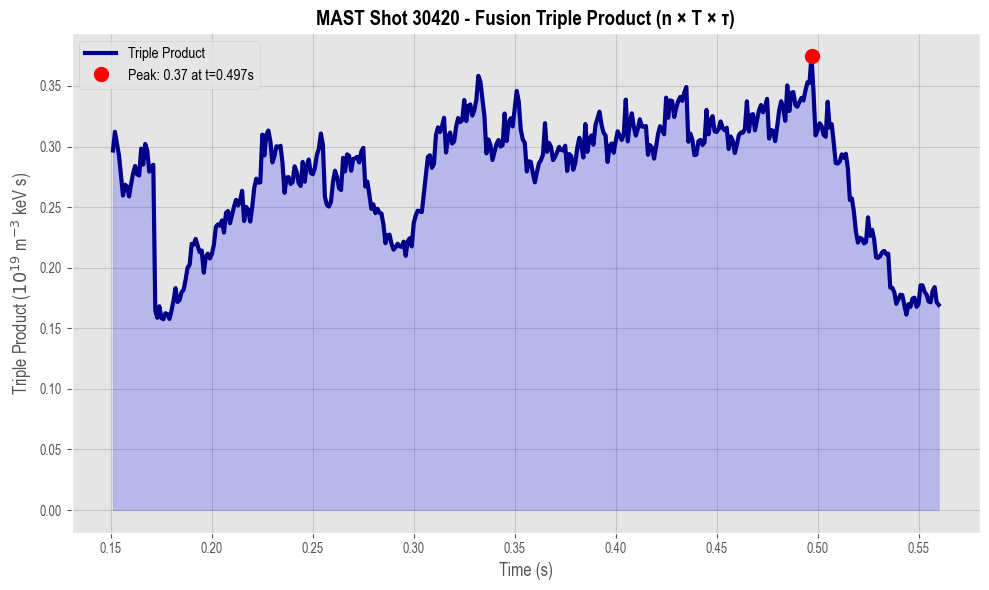

In [15]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(time, triple_product / 1e19, 'darkblue', linewidth=3, label='Triple Product')
ax.fill_between(time, 0, triple_product / 1e19, alpha=0.2, color='blue')

# Mark peak
peak_idx = np.nanargmax(triple_product)
ax.plot(time[peak_idx], triple_product[peak_idx] / 1e19, 'ro', markersize=10, 
        label=f'Peak: {triple_product[peak_idx]/1e19:.2f} at t={time[peak_idx]:.3f}s')

ax.set_xlabel('Time (s)', fontsize=13)
ax.set_ylabel('Triple Product ($10^{19}$ m$^{-3}$ keV s)', fontsize=13)
ax.set_title('MAST Shot 30420 - Fusion Triple Product (n × T × τ)', fontsize=15, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=11)

plt.tight_layout()
plt.show()

## Summary Statistics

In [16]:
import pandas as pd

# Create summary DataFrame
summary_data = {
    'Parameter': [
        'Peak Density', 
        'Peak Temperature', 
        'Peak Confinement Time',
        'Peak Stored Energy',
        'Average Plasma Volume',
        'Peak Triple Product',
        'Average Triple Product',
        'Time of Peak nTτ'
    ],
    'Value': [
        f"{np.nanmax(n_e):.2e} m⁻³",
        f"{np.nanmax(T_e_keV):.2f} keV",
        f"{np.nanmax(tau_e)*1000:.2f} ms",
        f"{np.nanmax(wmhd_interp)/1e3:.2f} kJ",
        f"{np.nanmean(V_plasma):.2f} m³",
        f"{np.nanmax(triple_product):.2e} m⁻³ keV s",
        f"{np.nanmean(triple_product[~np.isnan(triple_product)]):.2e} m⁻³ keV s",
        f"{time[np.nanargmax(triple_product)]:.3f} s"
    ]
}

summary_df = pd.DataFrame(summary_data)
summary_df

,Parameter,Value
0,Peak Density,3.56e+19 m⁻³
1,Peak Temperature,3.44 keV
2,Peak Confinement Time,49.75 ms
3,Peak Stored Energy,137.47 kJ
4,Average Plasma Volume,7.06 m³
5,Peak Triple Product,3.75e+18 m⁻³ keV s
6,Average Triple Product,2.77e+18 m⁻³ keV s
7,Time of Peak nTτ,0.497 s
